# Step 4 - MedEV Result Analysis

This notebook summarizes translation performance and produces report-ready tables/figures for thesis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sacrebleu.metrics import BLEU, CHRF, TER

OUT_DIR = "outputs_medev"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

OVERALL_PATH = os.path.join(OUT_DIR, "results_overall.csv")
BY_BIN_PATH = os.path.join(OUT_DIR, "results_by_length_bin.csv")
GPT_PATH = os.path.join(OUT_DIR, "translations_gpt.csv")
GEMINI_PATH = os.path.join(OUT_DIR, "translations_gemini.csv")

overall = pd.read_csv(OVERALL_PATH)
by_bin = pd.read_csv(BY_BIN_PATH)
gpt_df = pd.read_csv(GPT_PATH)
gemini_df = pd.read_csv(GEMINI_PATH)

print("Loaded results")
display(overall)
display(by_bin.head())

Loaded results


,Model,BLEU,chrF++,TER
0,GPT-5.2,33.383,59.609,59.983
1,Gemini-2.5-Flash,38.274,61.808,54.977


,Model,LengthBin,n,BLEU,chrF++,TER
0,GPT-5.2,1-10,599,33.936,55.813,63.562
1,GPT-5.2,11-20,2391,31.886,57.882,61.841
2,GPT-5.2,21-35,3378,32.782,59.234,59.810
3,GPT-5.2,36+,2591,34.182,60.532,59.399
4,Gemini-2.5-Flash,1-10,599,37.635,57.476,58.372


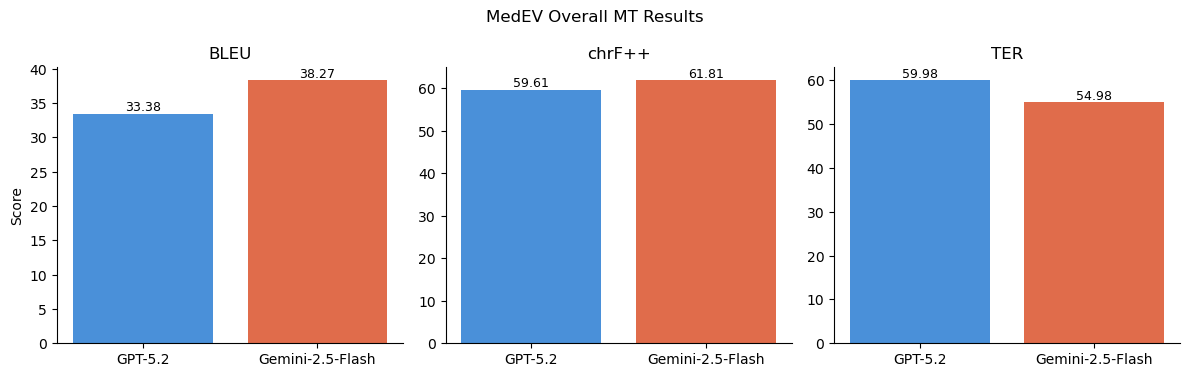

,Model,BLEU,chrF++,TER
0,GPT-5.2,33.383,59.609,59.983
1,Gemini-2.5-Flash,38.274,61.808,54.977


In [2]:
# RQ1: Overall performance comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
metrics = ["BLEU", "chrF++", "TER"]
colors = ["#4a90d9", "#e06c4b"]

for ax, m in zip(axes, metrics):
    vals = overall[m].values
    bars = ax.bar(overall["Model"], vals, color=colors)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(m)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Score")
plt.suptitle("MedEV Overall MT Results")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq1_overall_metrics.png"), dpi=150)
plt.show()

overall

Model,GPT-5.2,Gemini-2.5-Flash
LengthBin,,
1-10,33.936,37.635
11-20,31.886,36.024
21-35,32.782,37.108
36+,34.182,39.603


Model,GPT-5.2,Gemini-2.5-Flash
LengthBin,,
1-10,55.813,57.476
11-20,57.882,59.057
21-35,59.234,60.767
36+,60.532,63.505


Model,GPT-5.2,Gemini-2.5-Flash
LengthBin,,
1-10,63.562,58.372
11-20,61.841,56.555
21-35,59.810,55.196
36+,59.399,54.211


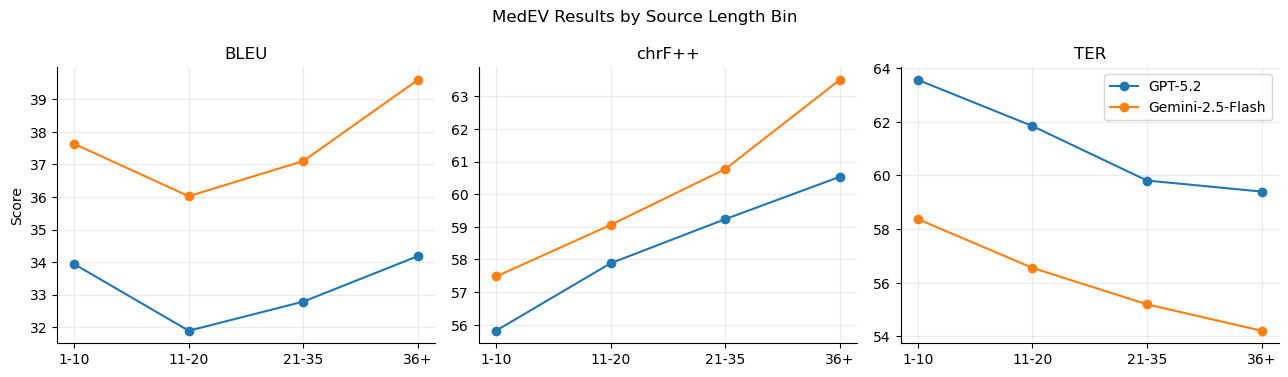

In [3]:
# RQ2: Performance by Vietnamese source length
for metric in ["BLEU", "chrF++", "TER"]:
    piv = by_bin.pivot(index="LengthBin", columns="Model", values=metric)
    display(piv)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, metric in zip(axes, ["BLEU", "chrF++", "TER"]):
    for model, sub in by_bin.groupby("Model"):
        ax.plot(sub["LengthBin"], sub[metric], marker="o", label=model)
    ax.set_title(metric)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Score")
axes[-1].legend(loc="best")
plt.suptitle("MedEV Results by Source Length Bin")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rq2_by_length_bin.png"), dpi=150)
plt.show()

In [4]:
# RQ3/RQ4: Qualitative error analysis and medical-term subset
bleu_sent = BLEU(effective_order=True)
ter_sent = TER()

cmp = gpt_df[["id", "source_vi", "reference_en", "translated_en"]].rename(columns={"translated_en": "gpt_en"})
cmp = cmp.merge(
    gemini_df[["id", "translated_en"]].rename(columns={"translated_en": "gemini_en"}),
    on="id",
    how="inner",
)

cmp["gpt_bleu_sent"] = cmp.apply(lambda r: bleu_sent.sentence_score(str(r["gpt_en"]), [str(r["reference_en"])]).score, axis=1)
cmp["gemini_bleu_sent"] = cmp.apply(lambda r: bleu_sent.sentence_score(str(r["gemini_en"]), [str(r["reference_en"])]).score, axis=1)
cmp["gpt_ter_sent"] = cmp.apply(lambda r: ter_sent.sentence_score(str(r["gpt_en"]), [str(r["reference_en"])]).score, axis=1)
cmp["gemini_ter_sent"] = cmp.apply(lambda r: ter_sent.sentence_score(str(r["gemini_en"]), [str(r["reference_en"])]).score, axis=1)
cmp["winner_bleu"] = np.where(cmp["gemini_bleu_sent"] > cmp["gpt_bleu_sent"], "Gemini", np.where(cmp["gemini_bleu_sent"] < cmp["gpt_bleu_sent"], "GPT", "Tie"))

qual_path = os.path.join(OUT_DIR, "qualitative_compare.csv")
cmp.to_csv(qual_path, index=False, encoding="utf-8")
print(f"Saved -> {qual_path}")

print("Winner count (sentence BLEU):")
print(cmp["winner_bleu"].value_counts())

print("\nTop 10 hardest samples by best sentence BLEU (lower is harder):")
display(cmp.assign(best_bleu=cmp[["gpt_bleu_sent", "gemini_bleu_sent"]].max(axis=1)).nsmallest(10, "best_bleu")[["id", "source_vi", "reference_en", "gpt_en", "gemini_en", "gpt_bleu_sent", "gemini_bleu_sent"]])

# Medical-keyword subset
medical_keywords = ["thuoc", "benh", "dieu tri", "chan doan", "trieu chung", "phau thuat", "xet nghiem", "benh nhan"]
mask_med = cmp["source_vi"].astype(str).str.lower().apply(lambda t: any(k in t for k in medical_keywords))
med_subset = cmp[mask_med]
print(f"\nKeyword medical subset rows: {len(med_subset):,}")
if len(med_subset) > 0:
    med_summary = pd.DataFrame([
        {
            "Subset": "Medical-keyword",
            "GPT_sentence_BLEU_mean": round(med_subset["gpt_bleu_sent"].mean(), 3),
            "Gemini_sentence_BLEU_mean": round(med_subset["gemini_bleu_sent"].mean(), 3),
            "GPT_sentence_TER_mean": round(med_subset["gpt_ter_sent"].mean(), 3),
            "Gemini_sentence_TER_mean": round(med_subset["gemini_ter_sent"].mean(), 3),
        }
    ])
    display(med_summary)

Saved -> outputs_medev\qualitative_compare.csv
Winner count (sentence BLEU):
winner_bleu
Gemini    5161
GPT       2882
Tie        916
Name: count, dtype: int64

Top 10 hardest samples by best sentence BLEU (lower is harder):


,id,source_vi,reference_en,gpt_en,gemini_en,gpt_bleu_sent,gemini_bleu_sent
294,295,Rối loạn lipid máu do thuốc,Drug - Induced Dyslipidemia,Drug-induced dyslipidemia,Drug-induced dyslipidemia,0.000000,0.000000
456,457,"Nhận xét một số đặc điểm lâm sàng, cận lâm sàn...",ASSESSMENT THE CLINICAL AND SUBCLINICAL IN PAT...,Commentary on certain clinical and paraclinica...,Review some clinical and subclinical character...,0.000000,0.000000
7938,7939,Chẩn đoán block nhĩ thất bằng điện tâm đồ.,Diagnosis is by electrocardiography; symptoms ...,Diagnose atrioventricular block using electroc...,Diagnose atrioventricular block using an elect...,0.531834,0.688537
2333,2334,Các bệnh nhân này được STTQD giữa 2 chu kỳ chạ...,"In these patients, the kidney biopsy was done ...",These patients underwent percutaneous renal bi...,These patients were transfused between hemodia...,1.091070,0.565744
5311,5312,Khẩu phần ăn thực tế của bệnh nhân ung thư phụ...,Chế độ ăn thực tế của bệnh nhân ung thư phụ kh...,The actual dietary intake of most patients wit...,The actual diet of gynecological cancer patien...,1.128052,1.076502
1728,1729,Phương pháp nghiên cứu: Nghiên cứu hàng loạt c...,Phương pháp nghiên cứu: Nghiên cứu hàng loạt c...,Methods: A case series study was conducted fro...,Research methods: A case series study was cond...,1.484546,0.822293
3177,3178,Mục tiêu nghiên cứu: Theo dõi mức độ tồn lưu á...,Objective: 4 different risk categories of mini...,Study objective: To monitor the level of resid...,Research objective: To monitor the level of ma...,1.547285,1.510852
3313,3314,Tất cả BN cương được đều cho biết hình thái củ...,All of patients have declared that their erect...,All patients who were able to achieve an erect...,All patients who achieved an erection reported...,1.552979,1.537320
2857,2858,Kết luận: Trong điều kiện chăm sóc y tế giản đ...,Conclusions: In the situation of carrying simp...,Conclusion: Under basic healthcare conditions ...,Conclusion: Under simplified medical care cond...,1.537937,1.709516
1926,1927,Tỷ lệ chấn thương sọ não trong thời gian khảo ...,Rate of head injury in time - when the study h...,The incidence of traumatic brain injury during...,The rate of traumatic brain injury during the ...,1.734562,1.877081



Keyword medical subset rows: 0
